## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
import lightgbm as lgb
from geopy.distance import geodesic
import joblib

## Loading dataset

In [2]:
dataset = pd.read_csv("Transaction_dataset.csv")
dataset.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Data Preprocessing 

In [3]:
dataset.shape

(1852394, 23)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  object 
 2   cc_num                 int64  
 3   merchant               object 
 4   category               object 
 5   amt                    float64
 6   first                  object 
 7   last                   object 
 8   gender                 object 
 9   street                 object 
 10  city                   object 
 11  state                  object 
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    object 
 17  dob                    object 
 18  trans_num              object 
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud          

In [5]:
dataset.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [6]:
dataset['trans_date_trans_time'] = pd.to_datetime(dataset['trans_date_trans_time'])

dataset['hour'] = dataset['trans_date_trans_time'].dt.hour
dataset['day'] = dataset['trans_date_trans_time'].dt.day
dataset['month'] = dataset['trans_date_trans_time'].dt.month

In [7]:
drop = ['Unnamed: 0', 'first', 'last', 'street', 'zip', 'dob', 'job', 'trans_num', 'state']
df = dataset.drop(columns=drop)

In [8]:
cat_col = ['merchant', 'category', 'gender', 'city']
encoders = {}
for col in cat_col:
    encoders[col]=LabelEncoder()
    df[col]=encoders[col].fit_transform(df[col])

In [9]:
# number of legit transactions & fraud transactions
df['is_fraud'].value_counts()

is_fraud
0    1842743
1       9651
Name: count, dtype: int64

In [10]:
# separating the data for analysis
normal_transaction = df[df.is_fraud == 0]
fraud_transaction = df[df.is_fraud == 1]

In [11]:
normal_transaction.amt.describe()

count    1.842743e+06
mean     6.765128e+01
std      1.535481e+02
min      1.000000e+00
25%      9.610000e+00
50%      4.724000e+01
75%      8.256000e+01
max      2.894890e+04
Name: amt, dtype: float64

In [12]:
fraud_transaction.amt.describe()

count    9651.000000
mean      530.661412
std       391.028873
min         1.060000
25%       240.075000
50%       390.000000
75%       902.365000
max      1376.040000
Name: amt, dtype: float64

### Under Sampling
Building a sample dataset of normal tranaction containing similar distribution as Fraudulent Transactions 

In [13]:
normal_transaction_sample = normal_transaction.sample(n=9651)

### Combining both datasets of same distribution

In [14]:
df= pd.concat([normal_transaction_sample, fraud_transaction], axis=0)

In [15]:
df['is_fraud'].value_counts()

is_fraud
0    9651
1    9651
Name: count, dtype: int64

In [16]:
def haversine(lat1, lon1, lat2, lon2):
    return np.array([geodesic((a,b),(c,d)).km for a,b,c,d in zip(lat1, lon1, lat2, lon2)])

df['distance'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

### Splitting the data into Features & Targets

In [17]:
features = ['merchant', 'category', 'amt', 'cc_num', 'hour', 'day', 'month', 'gender', 'city', 'distance']
x = df[features]
y = df['is_fraud']

### Spliting the dataset into Training data & Testing Data

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Model training (LightGBM Classifier)

In [19]:
lgb_model = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metrics='auc',
    is_unbalance=True,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=1,
    n_estimators=200
)
lgb_model.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 7719, number of negative: 7722
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1354
[LightGBM] [Info] Number of data points in the train set: 15441, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499903 -> initscore=-0.000389
[LightGBM] [Info] Start training from score -0.000389
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

LGBMClassifier(is_unbalance=True, learning_rate=0.05, max_depth=1,
               metrics='auc', n_estimators=200, objective='binary')

In [20]:
y_pred = lgb_model.predict(x_test)

## Model Evaluation

In [21]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Roc AUC Score: ", roc_auc_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      1929
           1       0.94      0.92      0.93      1932

    accuracy                           0.93      3861
   macro avg       0.93      0.93      0.93      3861
weighted avg       0.93      0.93      0.93      3861

Roc AUC Score:  0.9272291342664593


In [22]:
fpr, tpr, thresholds = roc_curve(y_test, lgb_model.predict_proba(x_test)[:,1])
roc_auc = auc(fpr, tpr)

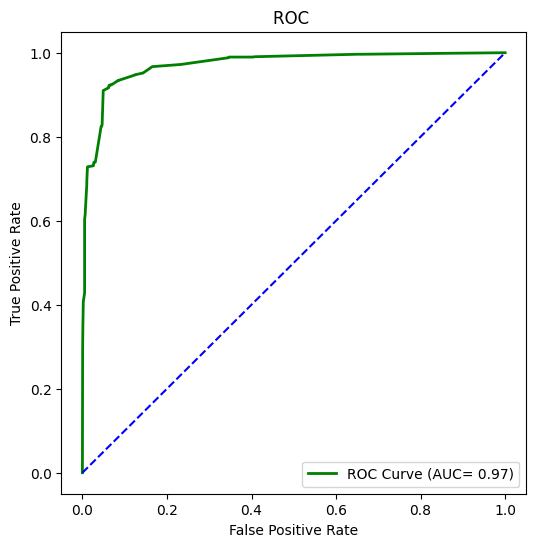

In [23]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="green", lw=2, label=f'ROC Curve (AUC= {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='blue', linestyle='--')
plt.title('ROC ')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc="lower right")
plt.show()

In [24]:
joblib.dump(lgb_model, "Credit_Card_Fraud_Detection.jb")
joblib.dump(encoders, "label_encoder.jb")

['label_encoder.jb']